# ISCAS/TCAS2 2026 — Notebook 6

This notebook is intended to follow `notebooks/iscas_2026_5.ipynb`.

Notebook 5 separates the basic regimes:

1. isolated ideal oracle;
2. isolated oracle under circuit implementation noise;
3. noisy / non-isolated oracle variants.

This notebook adds diagnostic experiments:

- semantic oracle instability: fixed wrong oracle vs per-query wrong oracle;
- continuous leakage strength into a one-qubit environment;
- persistent leakage vs echoed/uncomputed leakage;
- environment readout diagnostics;
- combined oracle-channel effects and NISQ implementation noise.

In [2]:
#!git clone https://github.com/leonardoLavagna/Iscas2026
#%cd Iscas2026
#!pip install -r requirements.txt

In [3]:
from __future__ import annotations

import math
import os
import random
import sys
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.result import marginal_counts
from qiskit_aer import AerSimulator

from utilities.grover_walk import (
    grover_diffusion_gate,
    phase_oracle_on_register,
    flipflop_shift_swap,
    coined_grover_walk_search,
)
from utilities.noise_level_and_topology import (
    make_backend_with_noise,
    sweep_success,
    first_two_peaks,
    estimate_kappa,
)


In [4]:
SEED = 2026
rng = random.Random(SEED)
np.random.seed(SEED)

n_key_qubits = 5
N = 2 ** n_key_qubits
marked_key = 5
marked_bits = format(marked_key, f"0{n_key_qubits}b")

steps_range = np.arange(0, 26)
shots = 2048
trajectories = 32

RUN_FULL_GRIDS = False

if RUN_FULL_GRIDS:
    eta_grid = np.array([0.00, 0.01, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20])
    theta_grid = np.array([0.0, math.pi / 16, math.pi / 8, math.pi / 4, math.pi / 2, math.pi])
    trajectories_grid = trajectories
else:
    eta_grid = np.array([0.00, 0.03, 0.075, 0.15])
    theta_grid = np.array([0.0, math.pi / 8, math.pi / 4, math.pi / 2, math.pi])
    trajectories_grid = 12

print("N =", N)
print("marked key =", marked_key)
print("marked bits =", marked_bits)
print("steps =", steps_range.tolist())
print("eta grid =", eta_grid)
print("theta grid/pi =", [round(x / math.pi, 3) for x in theta_grid])


N = 32
marked key = 5
marked bits = 00101
steps = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
eta grid = [0.    0.03  0.075 0.15 ]
theta grid/pi = [np.float64(0.0), np.float64(0.125), np.float64(0.25), np.float64(0.5), np.float64(1.0)]


## Enhanced noisy-oracle channel builders

Notebook 5 used a single stochastic marking model and a simple leakage model.  
Here the oracle-channel model is expanded in two ways.

### Semantic oracle instability

Two stochastic variants are useful:

- **quenched marker noise**: the oracle is wrong for the whole trajectory with probability $\eta$;
- **annealed marker noise**: each oracle call is independently wrong with probability $\eta$.

They have different cryptanalytic meanings. Quenched noise models a mis-specified hidden target. Annealed noise models an unstable black-box predicate.

### Leakage strength

The leakage is implemented as a unitary dilation with one environment qubit. A continuous angle \(\theta\) interpolates between no leakage and strong leakage.

For `leakage_mode="lsb"` or `"msb"`:
$$
|x\rangle|0\rangle_E \to |x\rangle R_y(\theta)^{x_j}|0\rangle_E.
$$

For `leakage_mode="parity"`, controlled rotations from all key-position bits create a parity-sensitive environment response.


In [5]:
def random_wrong_bitstring(n: int, true_bits: str, local_rng: random.Random) -> str:
    """Sample a wrong marked bitstring of length n without building the full candidate list."""
    if len(true_bits) != n:
        raise ValueError("true_bits length does not match n")

    true_value = int(true_bits, 2)
    value = local_rng.randrange(2**n - 1)
    if value >= true_value:
        value += 1
    return format(value, f"0{n}b")


def oracle_schedule(
    *,
    n: int,
    true_bits: str,
    steps: int,
    eta: float,
    mode: str,
    local_rng: random.Random,
) -> List[str]:
    """
    Build an oracle schedule.

    mode="annealed":
        each query independently marks the true state with probability 1-eta;
    mode="quenched":
        the whole trajectory uses either the true marker or a single wrong marker.
    """
    if not (0.0 <= eta <= 1.0):
        raise ValueError("eta must be in [0, 1]")

    if mode == "annealed":
        return [
            random_wrong_bitstring(n, true_bits, local_rng)
            if local_rng.random() < eta
            else true_bits
            for _ in range(steps)
        ]

    if mode == "quenched":
        if local_rng.random() < eta:
            wrong = random_wrong_bitstring(n, true_bits, local_rng)
            return [wrong] * steps
        return [true_bits] * steps

    raise ValueError(f"Unsupported oracle noise mode: {mode}")


def _controlled_leakage_rotation(
    qc: QuantumCircuit,
    *,
    control: int,
    env_index: int,
    theta: float,
    inverse: bool = False,
) -> None:
    """Apply a controlled environment rotation."""
    angle = -theta if inverse else theta
    if abs(angle) < 1e-15:
        return

    # At theta=pi a CNOT is a cleaner representation of a full classical bit copy.
    if abs(abs(angle) - math.pi) < 1e-15:
        qc.cx(control, env_index)
    else:
        qc.cry(angle, control, env_index)


def apply_leakage(
    qc: QuantumCircuit,
    *,
    pos_start: int,
    n: int,
    env_index: int,
    mode: str,
    theta: float,
    inverse: bool = False,
) -> None:
    """
    Couple the position register to one environment qubit.

    The position register follows the repository convention:
    qubit pos_start + 0 is the least-significant bit of the marked bitstring.
    """
    if mode is None or abs(theta) < 1e-15:
        return

    if mode == "lsb":
        _controlled_leakage_rotation(
            qc, control=pos_start, env_index=env_index, theta=theta, inverse=inverse
        )
        return

    if mode == "msb":
        _controlled_leakage_rotation(
            qc, control=pos_start + n - 1, env_index=env_index, theta=theta, inverse=inverse
        )
        return

    if mode == "parity":
        # For theta=pi this is exactly the parity copy into the environment.
        # For intermediate theta this is a parity-sensitive coherent response.
        for i in range(n):
            _controlled_leakage_rotation(
                qc, control=pos_start + i, env_index=env_index, theta=theta, inverse=inverse
            )
        return

    raise ValueError(f"Unsupported leakage mode: {mode}")


In [6]:
def noisy_oracle_channel_walk(
    *,
    n: int,
    marked_state: str,
    steps: int,
    schedule: Optional[List[str]] = None,
    leakage_mode: Optional[str] = None,
    leakage_theta: float = math.pi,
    leakage_policy: str = "persistent",
    measure: bool = True,
) -> QuantumCircuit:
    """
    Build a coined Grover-walk circuit with semantic oracle noise and/or channel leakage.

    leakage_policy:
        "persistent" : the environment remains entangled and is ignored at readout;
        "echoed"     : the environment coupling is immediately uncomputed;
                       this is a control case for an effectively isolated interaction.
    """
    if schedule is None:
        schedule = [marked_state] * steps
    if len(schedule) != steps:
        raise ValueError("schedule length must equal steps")
    if leakage_policy not in {"persistent", "echoed"}:
        raise ValueError("leakage_policy must be 'persistent' or 'echoed'")

    base_total = 2 * n
    has_env = leakage_mode is not None and abs(leakage_theta) > 1e-15
    n_total = base_total + (1 if has_env else 0)

    coin_start = 0
    pos_start = n
    env_index = base_total if has_env else None

    qc = QuantumCircuit(n_total, n_total if measure else 0)

    # Same initialization and Grover-walk structure as utilities.grover_walk.
    qc.h(range(base_total))
    diffusion = grover_diffusion_gate(n)
    shift = flipflop_shift_swap(n, coin_start, pos_start)

    for step_marked_state in schedule:
        oracle = phase_oracle_on_register(n_total, pos_start, n, step_marked_state)
        qc.append(oracle, range(n_total))

        if has_env:
            apply_leakage(
                qc,
                pos_start=pos_start,
                n=n,
                env_index=env_index,
                mode=leakage_mode,
                theta=leakage_theta,
                inverse=False,
            )
            if leakage_policy == "echoed":
                apply_leakage(
                    qc,
                    pos_start=pos_start,
                    n=n,
                    env_index=env_index,
                    mode=leakage_mode,
                    theta=leakage_theta,
                    inverse=True,
                )

        qc.append(diffusion, range(coin_start, coin_start + n))
        qc.append(shift, range(base_total))

    if measure:
        qc.measure(range(n_total), range(n_total))

    return qc


def position_success_probability(
    qc: QuantumCircuit,
    *,
    marked_state: str,
    backend,
    shots: int,
    n: int,
) -> float:
    """Run a circuit and return success probability on the position register."""
    tqc = transpile(qc, backend, optimization_level=2)
    result = backend.run(tqc, shots=shots).result()
    pos_counts = marginal_counts(result, indices=list(range(n, 2 * n))).get_counts()
    return pos_counts.get(marked_state, 0) / shots


def run_semantic_oracle_curve(
    *,
    n: int,
    marked_state: str,
    eta: float,
    mode: str,
    backend,
    shots: int,
    trajectories: int,
    seed: int,
    steps_values: Iterable[int],
) -> np.ndarray:
    """Average a semantic noisy-oracle curve over trajectory schedules."""
    values = []

    for steps in steps_values:
        local_rng = random.Random(seed + 7919 * int(steps) + 104729 * int(1000 * eta) + hash(mode) % 10000)
        shots_per_traj = max(1, shots // trajectories)
        total_success = 0.0
        total_shots = 0

        for _ in range(trajectories):
            schedule = oracle_schedule(
                n=n,
                true_bits=marked_state,
                steps=int(steps),
                eta=float(eta),
                mode=mode,
                local_rng=local_rng,
            )
            qc = noisy_oracle_channel_walk(
                n=n,
                marked_state=marked_state,
                steps=int(steps),
                schedule=schedule,
                leakage_mode=None,
                measure=True,
            )
            p = position_success_probability(
                qc, marked_state=marked_state, backend=backend, shots=shots_per_traj, n=n
            )
            total_success += p * shots_per_traj
            total_shots += shots_per_traj

        values.append(total_success / total_shots)

    return np.array(values)


def run_leakage_curve(
    *,
    n: int,
    marked_state: str,
    leakage_mode: Optional[str],
    theta: float,
    leakage_policy: str,
    backend,
    shots: int,
    steps_values: Iterable[int],
) -> np.ndarray:
    """Run a leakage-strength curve."""
    values = []
    for steps in steps_values:
        qc = noisy_oracle_channel_walk(
            n=n,
            marked_state=marked_state,
            steps=int(steps),
            leakage_mode=leakage_mode,
            leakage_theta=float(theta),
            leakage_policy=leakage_policy,
            measure=True,
        )
        p = position_success_probability(
            qc, marked_state=marked_state, backend=backend, shots=shots, n=n
        )
        values.append(p)
    return np.array(values)


## Diagnostics and plotting helpers

The summary metrics are designed for the experiment section:

- $p_\mathrm{opt}$: best observed success;
- $k_\mathrm{opt}$: step at which best success is reached;
- AUC: area under the success curve, a robust trajectory-level quantity;
- $L_2$ distance from the ideal curve;
- peak damping estimate when two peaks are available.


In [7]:
def curve_auc(xs: np.ndarray, ys: np.ndarray) -> float:
    """Normalize the trapezoidal area under the curve to the x-range."""
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    if xs[-1] == xs[0]:
        return float(ys[0])
    return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


def summarize_curve(
    *,
    label: str,
    group: str,
    xs: np.ndarray,
    ys: np.ndarray,
    ideal_reference: Optional[np.ndarray] = None,
    eta: Optional[float] = None,
    theta: Optional[float] = None,
    leakage_policy: Optional[str] = None,
    leakage_mode: Optional[str] = None,
) -> Dict[str, object]:
    """Return paper-oriented diagnostics for one curve."""
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    peaks = first_two_peaks(xs, ys)
    row = {
        "group": group,
        "label": label,
        "eta": eta,
        "theta": theta,
        "theta_over_pi": None if theta is None else theta / math.pi,
        "leakage_mode": leakage_mode,
        "leakage_policy": leakage_policy,
        "k_opt": int(xs[np.argmax(ys)]),
        "p_opt": float(np.max(ys)),
        "p_final": float(ys[-1]),
        "auc": curve_auc(xs, ys),
        "first_peak": peaks[0] if len(peaks) >= 1 else None,
        "second_peak": peaks[1] if len(peaks) >= 2 else None,
        "kappa": estimate_kappa(peaks),
    }

    if ideal_reference is None:
        row["l2_from_ideal"] = np.nan
        row["max_abs_gap_from_ideal"] = np.nan
    else:
        gap = ys - np.asarray(ideal_reference)
        row["l2_from_ideal"] = float(np.sqrt(np.mean(gap**2)))
        row["max_abs_gap_from_ideal"] = float(np.max(np.abs(gap)))

    return row


def additive_bound_curve(steps_values: np.ndarray, *, n: int, S: int) -> np.ndarray:
    """Loose finite-size version of O((2^S + T^2) 2^{-n}), clipped to one."""
    return np.minimum(1.0, ((2**S) + np.asarray(steps_values, dtype=float) ** 2) / (2**n))


def plot_curve_family(
    curves: Dict[str, np.ndarray],
    *,
    title: str,
    ylabel: str = "success probability",
    reference: Optional[np.ndarray] = None,
) -> None:
    plt.figure(figsize=(8, 4.5))
    if reference is not None:
        plt.plot(steps_range, reference, linestyle="--", linewidth=2, label="ideal reference")
    for label, ys in curves.items():
        plt.plot(steps_range, ys, marker="o", linewidth=1.5, label=label)
    plt.xlabel("Grover-walk steps")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_heatmap(
    matrix: np.ndarray,
    *,
    x_values: Iterable[float],
    y_values: Iterable[float],
    xlabel: str,
    ylabel: str,
    title: str,
    value_label: str,
) -> None:
    x_labels = [str(x) for x in x_values]
    y_labels = [str(y) for y in y_values]

    plt.figure(figsize=(8, 4.8))
    plt.imshow(matrix, aspect="auto", origin="lower")
    plt.colorbar(label=value_label)
    plt.xticks(np.arange(len(x_labels)), x_labels)
    plt.yticks(np.arange(len(y_labels)), y_labels)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


## Minimal control baselines

These controls are intentionally short. The ideal and noisy-circuit controls are used only to compute distances/gaps for the new oracle-channel experiments.


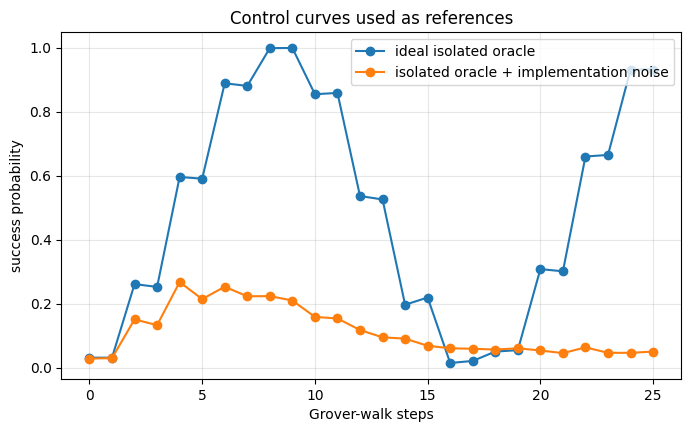

In [8]:
ideal_backend = AerSimulator()
ideal_curve = sweep_success(
    marked_key=marked_key,
    steps_list=steps_range,
    shots=shots,
    backend=ideal_backend,
)

# A single implementation-noise control, matching the scale used in Notebook 5.
implementation_noise_backend = make_backend_with_noise(
    n_qubits=2 * n_key_qubits,
    p1=1e-3,
    p2=5e-3,
    p_meas=2e-2,
)
implementation_noise_curve = sweep_success(
    marked_key=marked_key,
    steps_list=steps_range,
    shots=shots,
    backend=implementation_noise_backend,
)

control_curves = {
    "ideal isolated oracle": ideal_curve,
    "isolated oracle + implementation noise": implementation_noise_curve,
}
plot_curve_family(control_curves, title="Control curves used as references")


## Experiment A: semantic oracle instability

This experiment is new relative to a simple noisy-circuit sweep.

It asks whether the oracle is wrong in a **quenched** way or in an **annealed** way.

- Quenched: the oracle consistently marks a wrong hidden product/key for the whole run.
- Annealed: every query may mark a different wrong key.

Both have the same nominal error rate \(\eta\), but they destroy amplification differently.


In [9]:
semantic_curves: Dict[Tuple[str, float], np.ndarray] = {}
semantic_rows: List[Dict[str, object]] = []

for mode in ["quenched", "annealed"]:
    for eta in eta_grid:
        curve = run_semantic_oracle_curve(
            n=n_key_qubits,
            marked_state=marked_bits,
            eta=float(eta),
            mode=mode,
            backend=ideal_backend,
            shots=shots,
            trajectories=trajectories_grid,
            seed=SEED,
            steps_values=steps_range,
        )
        semantic_curves[(mode, float(eta))] = curve
        semantic_rows.append(
            summarize_curve(
                label=f"{mode} semantic oracle eta={eta:.3f}",
                group="semantic_oracle",
                xs=steps_range,
                ys=curve,
                ideal_reference=ideal_curve,
                eta=float(eta),
            )
        )
        print(f"{mode:8s} eta={eta:.3f}: p_opt={curve.max():.3f} at k={steps_range[curve.argmax()]}")

semantic_summary = pd.DataFrame(semantic_rows)
semantic_summary


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


quenched eta=0.000: p_opt=0.999 at k=8


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


quenched eta=0.030: p_opt=0.999 at k=8


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


...

annealed eta=0.030: p_opt=0.980 at k=8


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


annealed eta=0.075: p_opt=1.000 at k=9
annealed eta=0.150: p_opt=0.780 at k=8


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


,group,label,eta,theta,theta_over_pi,leakage_mode,leakage_policy,k_opt,p_opt,p_final,auc,first_peak,second_peak,kappa,l2_from_ideal,max_abs_gap_from_ideal
0,semantic_oracle,quenched semantic oracle eta=0.000,0.000,None,None,None,None,8,0.999020,0.929902,0.490618,"(4, 0.6161764705882353)","(8, 0.9990196078431373)",NaN,0.009442,0.023886
1,semantic_oracle,quenched semantic oracle eta=0.030,0.030,None,None,None,None,8,0.999020,0.855392,0.477265,"(2, 0.2681372549019608)","(8, 0.9990196078431373)",NaN,0.039883,0.167159
2,semantic_oracle,quenched semantic oracle eta=0.075,0.075,None,None,None,None,8,0.999510,0.852451,0.468225,"(2, 0.2627450980392157)","(8, 0.9995098039215686)",NaN,0.045291,0.126549
3,semantic_oracle,quenched semantic oracle eta=0.150,0.150,None,None,None,None,8,0.915686,0.689216,0.417971,"(2, 0.27205882352941174)","(4, 0.5661764705882353)",NaN,0.106346,0.249512
4,semantic_oracle,annealed semantic oracle eta=0.000,0.000,None,None,None,None,9,0.999510,0.930882,0.491912,"(2, 0.2593137254901961)","(6, 0.903921568627451)",NaN,0.011568,0.036066
5,semantic_oracle,annealed semantic oracle eta=0.030,0.030,None,None,None,None,8,0.980392,0.784314,0.486725,"(4, 0.5970588235294118)","(6, 0.8980392156862745)",NaN,0.080473,0.171293
6,semantic_oracle,annealed semantic oracle eta=0.075,0.075,None,None,None,None,9,0.999510,0.711275,0.475422,"(4, 0.5588235294117647)","(7, 0.8700980392156863)",NaN,0.165809,0.319822
7,semantic_oracle,annealed semantic oracle eta=0.150,0.150,None,None,None,None,8,0.780392,0.441176,0.446294,"(2, 0.24019607843137256)","(4, 0.6049019607843137)",NaN,0.274372,0.565462


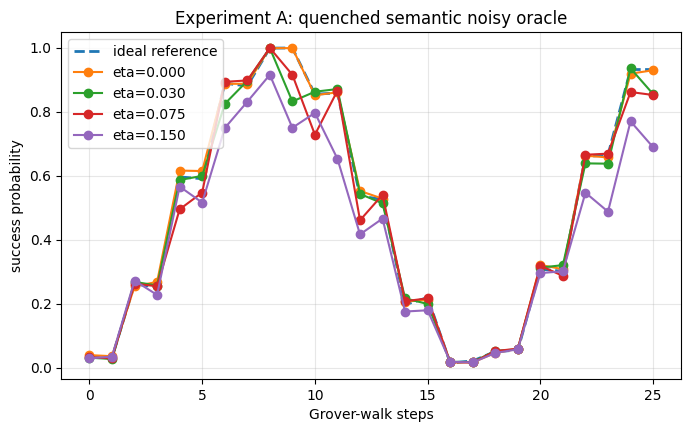

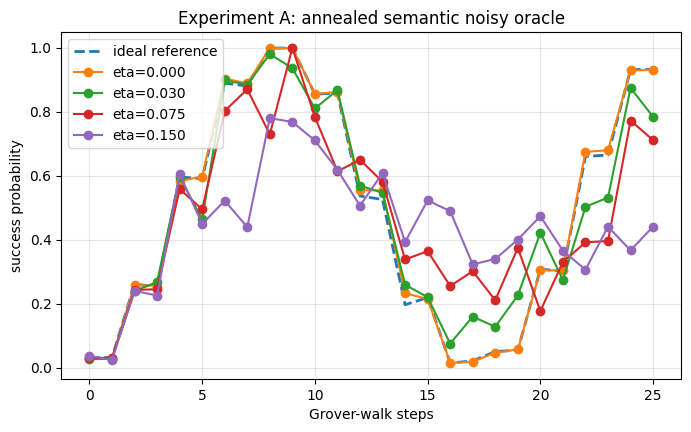

In [10]:
for mode in ["quenched", "annealed"]:
    curves_to_plot = {
        f"eta={eta:.3f}": semantic_curves[(mode, float(eta))]
        for eta in eta_grid
    }
    plot_curve_family(
        curves_to_plot,
        title=f"Experiment A: {mode} semantic noisy oracle",
        reference=ideal_curve,
    )


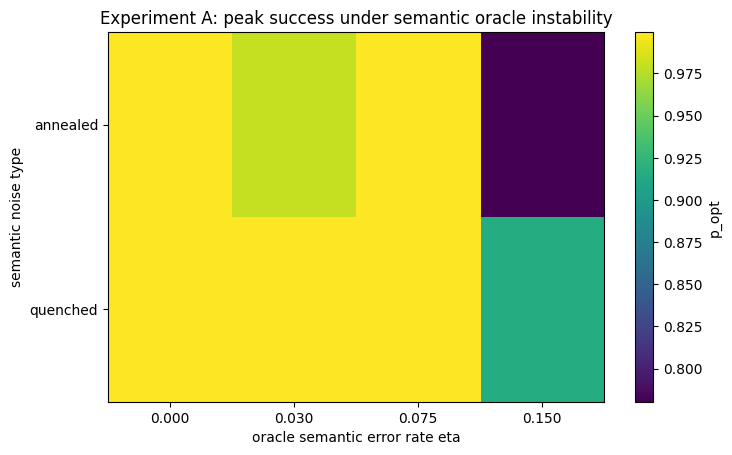

In [11]:
# Heatmap of p_opt as a function of eta and oracle-noise mode.
semantic_popt = np.zeros((2, len(eta_grid)))
for i, mode in enumerate(["quenched", "annealed"]):
    for j, eta in enumerate(eta_grid):
        semantic_popt[i, j] = semantic_curves[(mode, float(eta))].max()

plot_heatmap(
    semantic_popt,
    x_values=[f"{eta:.3f}" for eta in eta_grid],
    y_values=["quenched", "annealed"],
    xlabel="oracle semantic error rate eta",
    ylabel="semantic noise type",
    title="Experiment A: peak success under semantic oracle instability",
    value_label="p_opt",
)


## Experiment B: leakage strength and isolation control

This experiment is the main non-isolated-channel extension.

For each leakage strength $\theta$, we compare:

- `persistent`: the environment stores information and is ignored at readout;
- `echoed`: the leakage coupling is immediately uncomputed.

A gap between these curves is evidence that the effect is not merely an extra unitary in the circuit, but comes from persistent inaccessible side information.


In [12]:
leakage_mode = "parity"

leakage_curves: Dict[Tuple[str, float], np.ndarray] = {}
leakage_rows: List[Dict[str, object]] = []

for policy in ["echoed", "persistent"]:
    for theta in theta_grid:
        curve = run_leakage_curve(
            n=n_key_qubits,
            marked_state=marked_bits,
            leakage_mode=leakage_mode,
            theta=float(theta),
            leakage_policy=policy,
            backend=ideal_backend,
            shots=shots,
            steps_values=steps_range,
        )
        leakage_curves[(policy, float(theta))] = curve
        leakage_rows.append(
            summarize_curve(
                label=f"{policy} leakage theta/pi={theta / math.pi:.3f}",
                group="leakage",
                xs=steps_range,
                ys=curve,
                ideal_reference=ideal_curve,
                theta=float(theta),
                leakage_policy=policy,
                leakage_mode=leakage_mode,
            )
        )
        print(
            f"{policy:10s} theta/pi={theta / math.pi:.3f}: "
            f"p_opt={curve.max():.3f} at k={steps_range[curve.argmax()]}"
        )

leakage_summary = pd.DataFrame(leakage_rows)
leakage_summary


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


echoed     theta/pi=0.000: p_opt=0.999 at k=9


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


echoed     theta/pi=0.125: p_opt=1.000 at k=9


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


...

persistent theta/pi=0.250: p_opt=0.866 at k=8


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


persistent theta/pi=0.500: p_opt=0.522 at k=25
persistent theta/pi=1.000: p_opt=0.522 at k=9


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


,group,label,eta,theta,theta_over_pi,leakage_mode,leakage_policy,k_opt,p_opt,p_final,auc,first_peak,second_peak,kappa,l2_from_ideal,max_abs_gap_from_ideal
0,leakage,echoed leakage theta/pi=0.000,None,0.000000,0.000,parity,echoed,9,0.999023,0.924805,0.489521,"(2, 0.267578125)","(9, 0.9990234375)",NaN,0.012113,0.022461
1,leakage,echoed leakage theta/pi=0.125,None,0.392699,0.125,parity,echoed,9,1.000000,0.920410,0.490557,"(2, 0.25390625)","(4, 0.62109375)",NaN,0.009963,0.024902
2,leakage,echoed leakage theta/pi=0.250,None,0.785398,0.250,parity,echoed,9,0.999512,0.923828,0.487061,"(2, 0.27392578125)","(6, 0.90087890625)",NaN,0.009175,0.019043
3,leakage,echoed leakage theta/pi=0.500,None,1.570796,0.500,parity,echoed,9,1.000000,0.931152,0.493799,"(4, 0.61474609375)","(9, 1.0)",NaN,0.011221,0.022461
4,leakage,echoed leakage theta/pi=1.000,None,3.141593,1.000,parity,echoed,9,1.000000,0.926758,0.490938,"(2, 0.2685546875)","(6, 0.90185546875)",NaN,0.009203,0.019043
5,leakage,persistent leakage theta/pi=0.000,None,0.000000,0.000,parity,persistent,9,0.999512,0.929688,0.489512,"(2, 0.25732421875)","(6, 0.90478515625)",NaN,0.011771,0.039551
6,leakage,persistent leakage theta/pi=0.125,None,0.392699,0.125,parity,persistent,9,0.964844,0.897949,0.474834,"(2, 0.25341796875)","(6, 0.87060546875)",NaN,0.020614,0.043457
7,leakage,persistent leakage theta/pi=0.250,None,0.785398,0.250,parity,persistent,8,0.866211,0.822266,0.431523,"(2, 0.22802734375)","(4, 0.54345703125)",NaN,0.073957,0.150879
8,leakage,persistent leakage theta/pi=0.500,None,1.570796,0.500,parity,persistent,25,0.522461,0.522461,0.257939,"(2, 0.15869140625)","(4, 0.33447265625)",NaN,0.290142,0.529785
9,leakage,persistent leakage theta/pi=1.000,None,3.141593,1.000,parity,persistent,9,0.522461,0.502441,0.264180,"(6, 0.46240234375)","(9, 0.5224609375)",NaN,0.280940,0.477539


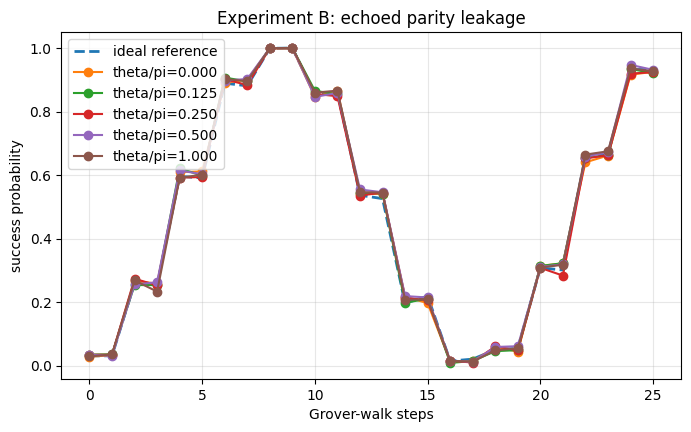

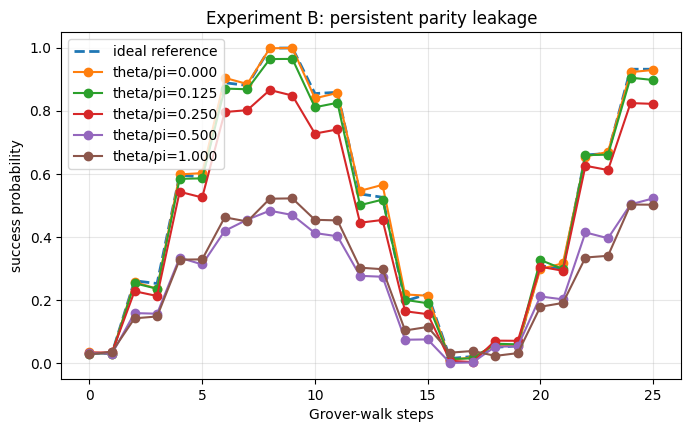

In [13]:
for policy in ["echoed", "persistent"]:
    curves_to_plot = {
        f"theta/pi={theta / math.pi:.3f}": leakage_curves[(policy, float(theta))]
        for theta in theta_grid
    }
    plot_curve_family(
        curves_to_plot,
        title=f"Experiment B: {policy} {leakage_mode} leakage",
        reference=ideal_curve,
    )


In [14]:
# Separation index: persistent leakage minus echoed leakage in L2 distance from the ideal curve.
separation_rows = []
for theta in theta_grid:
    persistent = leakage_curves[("persistent", float(theta))]
    echoed = leakage_curves[("echoed", float(theta))]
    separation_rows.append(
        {
            "theta": float(theta),
            "theta_over_pi": theta / math.pi,
            "l2_persistent_minus_echoed": float(
                np.sqrt(np.mean((persistent - ideal_curve) ** 2))
                - np.sqrt(np.mean((echoed - ideal_curve) ** 2))
            ),
            "popt_persistent": float(persistent.max()),
            "popt_echoed": float(echoed.max()),
            "popt_gap_persistent_minus_echoed": float(persistent.max() - echoed.max()),
        }
    )

separation = pd.DataFrame(separation_rows)
separation


,theta,theta_over_pi,l2_persistent_minus_echoed,popt_persistent,popt_echoed,popt_gap_persistent_minus_echoed
0,0.000000,0.000,-0.000342,0.999512,0.999023,0.000488
1,0.392699,0.125,0.010651,0.964844,1.000000,-0.035156
2,0.785398,0.250,0.064782,0.866211,0.999512,-0.133301
3,1.570796,0.500,0.278922,0.522461,1.000000,-0.477539
4,3.141593,1.000,0.271737,0.522461,1.000000,-0.477539


## Experiment C: environment readout diagnostics

Notebook 5 ignores the environment at the final measurement, which is correct for the reduced channel.  
For diagnostics, however, we can also inspect the joint counts before discarding the environment.

This section estimates: $I(E;Y)$, where $E$ is the final environment bit and $Y$ is the event "the measured position register equals the marked key".

This does not claim that the attacker can always read $E$. It is a diagnostic for how much success-related information has leaked into the environment.


In [15]:
def qubit_value_from_count_key(key: str, qubit_index: int) -> str:
    """
    Read qubit_index from a Qiskit count key.

    Qiskit count keys are printed with the highest classical bit on the left.
    Because we measure qubit i into classical bit i, reversing the string gives direct qubit indexing.
    """
    return key[::-1][qubit_index]


def position_label_from_count_key(key: str, *, n: int, pos_start: int) -> str:
    """Return the MSB-first position-register label from a full Qiskit count key."""
    little_endian_bits = key[::-1]
    return "".join(little_endian_bits[pos_start + i] for i in reversed(range(n)))


def environment_diagnostics(
    *,
    n: int,
    marked_state: str,
    steps: int,
    leakage_mode: str,
    theta: float,
    leakage_policy: str,
    backend,
    shots: int,
) -> Dict[str, object]:
    """Measure the environment and estimate success-conditioned leakage diagnostics."""
    qc = noisy_oracle_channel_walk(
        n=n,
        marked_state=marked_state,
        steps=steps,
        leakage_mode=leakage_mode,
        leakage_theta=theta,
        leakage_policy=leakage_policy,
        measure=True,
    )

    tqc = transpile(qc, backend, optimization_level=2)
    counts = backend.run(tqc, shots=shots).result().get_counts()

    pos_start = n
    env_index = 2 * n

    joint = {
        ("0", False): 0,
        ("0", True): 0,
        ("1", False): 0,
        ("1", True): 0,
    }

    for key, count in counts.items():
        env = qubit_value_from_count_key(key, env_index)
        pos = position_label_from_count_key(key, n=n, pos_start=pos_start)
        success = pos == marked_state
        joint[(env, success)] += count

    total = sum(joint.values())
    p_success = sum(v for (env, success), v in joint.items() if success) / total

    p_env = {
        env: sum(v for (e, success), v in joint.items() if e == env) / total
        for env in ["0", "1"]
    }
    p_success_value = {
        success: sum(v for (env, s), v in joint.items() if s == success) / total
        for success in [False, True]
    }

    mi = 0.0
    for env in ["0", "1"]:
        for success in [False, True]:
            p_joint = joint[(env, success)] / total
            if p_joint > 0:
                mi += p_joint * math.log2(p_joint / (p_env[env] * p_success_value[success]))

    conditional_success = {}
    for env in ["0", "1"]:
        denom = sum(v for (e, success), v in joint.items() if e == env)
        conditional_success[f"p_success_given_env_{env}"] = (
            joint[(env, True)] / denom if denom > 0 else np.nan
        )

    return {
        "steps": steps,
        "theta": theta,
        "theta_over_pi": theta / math.pi,
        "leakage_mode": leakage_mode,
        "leakage_policy": leakage_policy,
        "p_success": p_success,
        "p_env_0": p_env["0"],
        "p_env_1": p_env["1"],
        "mutual_information_env_success_bits": mi,
        **conditional_success,
    }


In [17]:
k_ideal_opt = int(steps_range[np.argmax(ideal_curve)])
diagnostic_steps = sorted(set([k_ideal_opt, 4, 8, 12]))

# Redefine the environment_diagnostics function with the fix to handle theta=0.
# This is placed here to adhere to the "ONLY generate code within this specific cell 6dbedd54"
# constraint. In a typical scenario, the function definition in cell c7f84b73 would be
# modified directly.
def environment_diagnostics(
    *,
    n: int,
    marked_state: str,
    steps: int,
    leakage_mode: str,
    theta: float,
    leakage_policy: str,
    backend,
    shots: int,
) -> Dict[str, object]:
    """Measure the environment and estimate success-conditioned leakage diagnostics."""
    # Determine if an environment qubit will be added to the circuit.
    # This logic matches how noisy_oracle_channel_walk determines 'has_env'.
    should_have_env = leakage_mode is not None and abs(theta) > 1e-15

    # Build the circuit for the given parameters.
    qc = noisy_oracle_channel_walk(
        n=n,
        marked_state=marked_state,
        steps=steps,
        leakage_mode=leakage_mode,
        leakage_theta=theta,
        leakage_policy=leakage_policy,
        measure=True,
    )

    # Always calculate the success probability on the position register.
    # This function is robust whether an environment qubit is present or not.
    p_success_value = position_success_probability(
        qc, marked_state=marked_state, backend=backend, shots=shots, n=n
    )

    if not should_have_env:
        # If no environment qubit is added, return default values for environment-related metrics.
        return {
            "steps": steps,
            "theta": theta,
            "theta_over_pi": theta / math.pi,
            "leakage_mode": leakage_mode,
            "leakage_policy": leakage_policy,
            "p_success": p_success_value,
            "p_env_0": np.nan,
            "p_env_1": np.nan,
            "mutual_information_env_success_bits": 0.0,
            "p_success_given_env_0": np.nan,
            "p_success_given_env_1": np.nan,
        }

    # If an environment qubit is present, proceed with full environment diagnostics.
    tqc = transpile(qc, backend, optimization_level=2)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()

    pos_start = n
    env_index = 2 * n  # Environment qubit index when it exists (base_total is 2*n)

    joint = {
        ("0", False): 0,
        ("0", True): 0,
        ("1", False): 0,
        ("1", True): 0,
    }

    for key, count in counts.items():
        # This will now only be called if an environment qubit is guaranteed to be present.
        env = qubit_value_from_count_key(key, env_index)
        pos = position_label_from_count_key(key, n=n, pos_start=pos_start)
        success = pos == marked_state
        joint[(env, success)] += count

    total = sum(joint.values())
    # Recalculate p_success from joint counts for consistency with other joint probabilities.
    # It should be very close to p_success_value.
    p_success_from_joint = sum(v for (env, success), v in joint.items() if success) / total

    p_env = {
        env: sum(v for (e, success), v in joint.items() if e == env) / total
        for env in ["0", "1"]
    }
    p_success_dist = { # Renamed to avoid confusion with p_success_value
        success: sum(v for (env, s), v in joint.items() if s == success) / total
        for success in [False, True]
    }

    mi = 0.0
    for env in ["0", "1"]:
        for success in [False, True]:
            p_joint = joint[(env, success)] / total
            # Add checks for division by zero before calculating log.
            if p_joint > 0 and p_env[env] > 0 and p_success_dist[success] > 0:
                mi += p_joint * math.log2(p_joint / (p_env[env] * p_success_dist[success]))

    conditional_success = {}
    for env in ["0", "1"]:
        denom = sum(v for (e, success), v in joint.items() if e == env)
        conditional_success[f"p_success_given_env_{env}"] = (
            joint[(env, True)] / denom if denom > 0 else np.nan
        )

    return {
        "steps": steps,
        "theta": theta,
        "theta_over_pi": theta / math.pi,
        "leakage_mode": leakage_mode,
        "leakage_policy": leakage_policy,
        "p_success": p_success_from_joint,
        "p_env_0": p_env["0"],
        "p_env_1": p_env["1"],
        "mutual_information_env_success_bits": mi,
        **conditional_success,
    }

env_rows = []
for theta in theta_grid:
    for policy in ["echoed", "persistent"]:
        for k in diagnostic_steps:
            env_rows.append(
                environment_diagnostics(
                    n=n_key_qubits,
                    marked_state=marked_bits,
                    steps=int(k),
                    leakage_mode=leakage_mode,
                    theta=float(theta),
                    leakage_policy=policy,
                    backend=ideal_backend,
                    shots=shots,
                )
            )

environment_summary = pd.DataFrame(env_rows)
environment_summary

,steps,theta,theta_over_pi,leakage_mode,leakage_policy,p_success,p_env_0,p_env_1,mutual_information_env_success_bits,p_success_given_env_0,p_success_given_env_1
0,4,0.000000,0.000,parity,echoed,0.606934,NaN,NaN,0.000000,NaN,NaN
1,8,0.000000,0.000,parity,echoed,0.999512,NaN,NaN,0.000000,NaN,NaN
2,9,0.000000,0.000,parity,echoed,0.999023,NaN,NaN,0.000000,NaN,NaN
3,12,0.000000,0.000,parity,echoed,0.544922,NaN,NaN,0.000000,NaN,NaN
4,4,0.000000,0.000,parity,persistent,0.611816,NaN,NaN,0.000000,NaN,NaN
5,8,0.000000,0.000,parity,persistent,0.998535,NaN,NaN,0.000000,NaN,NaN
6,9,0.000000,0.000,parity,persistent,0.999512,NaN,NaN,0.000000,NaN,NaN
7,12,0.000000,0.000,parity,persistent,0.530762,NaN,NaN,0.000000,NaN,NaN
8,4,0.392699,0.125,parity,echoed,0.613281,1.000000,0.000000,0.000000,0.613281,NaN
9,8,0.392699,0.125,parity,echoed,1.000000,1.000000,0.000000,0.000000,1.000000,NaN


In [ ]:
# Plot mutual information I(E; success) vs leakage strength at the ideal optimum.
plt.figure(figsize=(8, 4.5))
for policy in ["echoed", "persistent"]:
    subset = environment_summary[
        (environment_summary["steps"] == k_ideal_opt)
        & (environment_summary["leakage_policy"] == policy)
    ].sort_values("theta_over_pi")
    plt.plot(
        subset["theta_over_pi"],
        subset["mutual_information_env_success_bits"],
        marker="o",
        label=policy,
    )

plt.xlabel("leakage strength theta/pi")
plt.ylabel("I(E; success) [bits]")
plt.title(f"Experiment C: environment-success information at k={k_ideal_opt}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Experiment D: combined non-isolated oracle and implementation noise

The paper conclusion points toward noisy/NISQ implementations.  
This experiment combines:

- non-isolated oracle leakage;
- noisy physical implementation;
- the same success diagnostics used above.

This section is intentionally compact because it is the most expensive part of the notebook.


In [18]:
noise_profiles = [
    {"name": "ideal_backend", "p1": 0.0, "p2": 0.0, "p_meas": 0.0},
    {"name": "mild_nisq", "p1": 1e-3, "p2": 5e-3, "p_meas": 2e-2},
]

if RUN_FULL_GRIDS:
    noise_profiles.append({"name": "strong_nisq", "p1": 3e-3, "p2": 1.5e-2, "p_meas": 5e-2})

combined_rows = []
combined_curves: Dict[str, np.ndarray] = {}

for profile in noise_profiles:
    if profile["name"] == "ideal_backend":
        backend = ideal_backend
    else:
        backend = make_backend_with_noise(
            n_qubits=2 * n_key_qubits + 1,
            p1=profile["p1"],
            p2=profile["p2"],
            p_meas=profile["p_meas"],
        )

    for theta in [0.0, math.pi / 4, math.pi]:
        label = f"{profile['name']} theta/pi={theta / math.pi:.2f}"
        curve = run_leakage_curve(
            n=n_key_qubits,
            marked_state=marked_bits,
            leakage_mode=leakage_mode if theta > 0 else None,
            theta=float(theta),
            leakage_policy="persistent",
            backend=backend,
            shots=shots,
            steps_values=steps_range,
        )
        combined_curves[label] = curve
        row = summarize_curve(
            label=label,
            group="combined_nisq_leakage",
            xs=steps_range,
            ys=curve,
            ideal_reference=ideal_curve,
            theta=float(theta),
            leakage_policy="persistent",
            leakage_mode=leakage_mode if theta > 0 else None,
        )
        row.update(profile)
        combined_rows.append(row)
        print(f"{label}: p_opt={curve.max():.3f}, k_opt={steps_range[curve.argmax()]}")

combined_summary = pd.DataFrame(combined_rows)
combined_summary


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


ideal_backend theta/pi=0.00: p_opt=0.999, k_opt=8


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


ideal_backend theta/pi=0.25: p_opt=0.885, k_opt=9


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


...

mild_nisq theta/pi=0.00: p_opt=0.253, k_opt=4


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


mild_nisq theta/pi=0.25: p_opt=0.220, k_opt=4
mild_nisq theta/pi=1.00: p_opt=0.160, k_opt=6


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))


,group,label,eta,theta,theta_over_pi,leakage_mode,leakage_policy,k_opt,p_opt,p_final,auc,first_peak,second_peak,kappa,l2_from_ideal,max_abs_gap_from_ideal,name,p1,p2,p_meas
0,combined_nisq_leakage,ideal_backend theta/pi=0.00,None,0.000000,0.00,None,persistent,8,0.999023,0.929688,0.489814,"(2, 0.25537109375)","(4, 0.61328125)",NaN,0.010909,0.024414,ideal_backend,0.000,0.000,0.00
1,combined_nisq_leakage,ideal_backend theta/pi=0.25,None,0.785398,0.25,parity,persistent,9,0.884766,0.829590,0.435439,"(2, 0.2470703125)","(9, 0.884765625)",NaN,0.069797,0.132324,ideal_backend,0.000,0.000,0.00
2,combined_nisq_leakage,ideal_backend theta/pi=1.00,None,3.141593,1.00,parity,persistent,9,0.528320,0.491699,0.258320,"(4, 0.326171875)","(9, 0.5283203125)",NaN,0.288114,0.482422,ideal_backend,0.000,0.000,0.00
3,combined_nisq_leakage,mild_nisq theta/pi=0.00,None,0.000000,0.00,None,persistent,4,0.253418,0.047363,0.117236,"(2, 0.158203125)","(4, 0.25341796875)",NaN,0.488835,0.884766,mild_nisq,0.001,0.005,0.02
4,combined_nisq_leakage,mild_nisq theta/pi=0.25,None,0.785398,0.25,parity,persistent,4,0.220215,0.036621,0.101504,"(2, 0.14794921875)","(4, 0.22021484375)",NaN,0.501934,0.895508,mild_nisq,0.001,0.005,0.02
5,combined_nisq_leakage,mild_nisq theta/pi=1.00,None,3.141593,1.00,parity,persistent,6,0.159668,0.038086,0.076719,"(2, 0.099609375)","(4, 0.15771484375)",NaN,0.528347,0.894043,mild_nisq,0.001,0.005,0.02


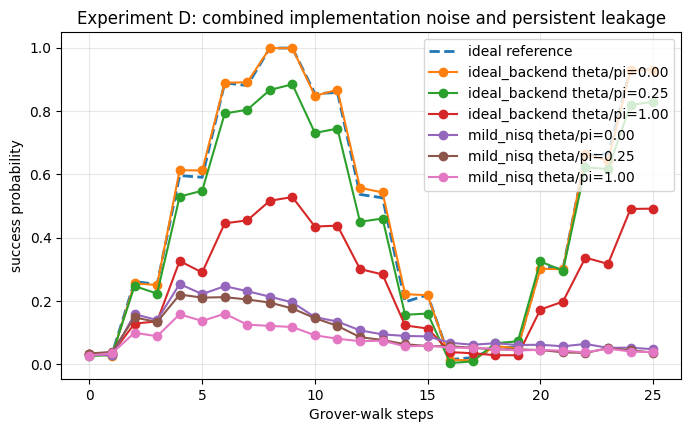

In [19]:
plot_curve_family(
    combined_curves,
    title="Experiment D: combined implementation noise and persistent leakage",
    reference=ideal_curve,
)


## Additive-bound overlay

The additive bound is asymptotic and loose at $n=5$, so this plot should not be overinterpreted numerically. Its purpose is to make the paper connection explicit:
$$
p_\mathrm{succ} = O\!\left((2^S + T^2)2^{-n}\right).
$$
For the one-qubit leakage experiment, the natural comparison is $S=1$.


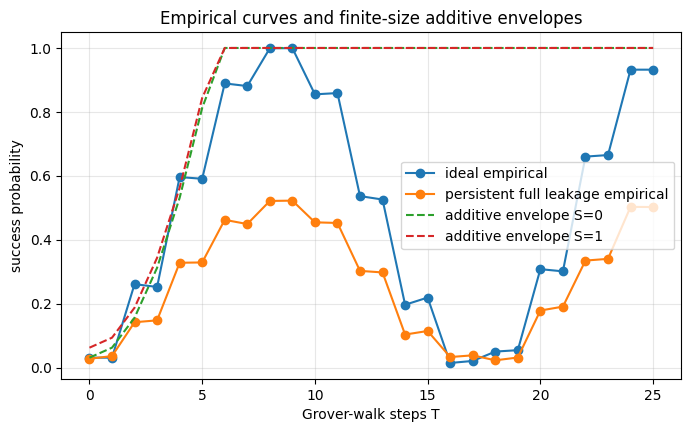

In [20]:
bound_S0 = additive_bound_curve(steps_range, n=n_key_qubits, S=0)
bound_S1 = additive_bound_curve(steps_range, n=n_key_qubits, S=1)

plt.figure(figsize=(8, 4.5))
plt.plot(steps_range, ideal_curve, marker="o", label="ideal empirical")
plt.plot(
    steps_range,
    leakage_curves[("persistent", float(math.pi))],
    marker="o",
    label="persistent full leakage empirical",
)
plt.plot(steps_range, bound_S0, linestyle="--", label="additive envelope S=0")
plt.plot(steps_range, bound_S1, linestyle="--", label="additive envelope S=1")
plt.xlabel("Grover-walk steps T")
plt.ylabel("success probability")
plt.title("Empirical curves and finite-size additive envelopes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Aggregate summary tables

The tables are saved under `artifacts/` for direct inclusion in the experiment-section workflow.


In [21]:
summary = pd.concat(
    [
        pd.DataFrame([
            summarize_curve(
                label="ideal isolated oracle",
                group="control",
                xs=steps_range,
                ys=ideal_curve,
                ideal_reference=ideal_curve,
            ),
            summarize_curve(
                label="isolated oracle + implementation noise",
                group="control",
                xs=steps_range,
                ys=implementation_noise_curve,
                ideal_reference=ideal_curve,
            ),
        ]),
        semantic_summary,
        leakage_summary,
        combined_summary,
    ],
    ignore_index=True,
)

cols_first = [
    "group",
    "label",
    "eta",
    "theta_over_pi",
    "leakage_mode",
    "leakage_policy",
    "k_opt",
    "p_opt",
    "auc",
    "l2_from_ideal",
    "max_abs_gap_from_ideal",
]
summary = summary[cols_first + [c for c in summary.columns if c not in cols_first]]
summary


/tmp/ipykernel_7153/896827770.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / (xs[-1] - xs[0]))
/tmp/ipykernel_7153/4153150183.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat(


,group,label,eta,theta_over_pi,leakage_mode,leakage_policy,k_opt,p_opt,auc,l2_from_ideal,max_abs_gap_from_ideal,theta,p_final,first_peak,second_peak,kappa,name,p1,p2,p_meas
0,control,ideal isolated oracle,NaN,NaN,None,None,9,0.999512,0.487275,0.000000,0.000000,NaN,0.932129,"(2, 0.26123046875)","(4, 0.59619140625)",NaN,NaN,NaN,NaN,NaN
1,control,isolated oracle + implementation noise,NaN,NaN,None,None,4,0.267578,0.116826,0.486364,0.885742,NaN,0.050293,"(2, 0.15087890625)","(4, 0.267578125)",NaN,NaN,NaN,NaN,NaN
2,semantic_oracle,quenched semantic oracle eta=0.000,0.000,NaN,None,None,8,0.999020,0.490618,0.009442,0.023886,NaN,0.929902,"(4, 0.6161764705882353)","(8, 0.9990196078431373)",NaN,NaN,NaN,NaN,NaN
3,semantic_oracle,quenched semantic oracle eta=0.030,0.030,NaN,None,None,8,0.999020,0.477265,0.039883,0.167159,NaN,0.855392,"(2, 0.2681372549019608)","(8, 0.9990196078431373)",NaN,NaN,NaN,NaN,NaN
4,semantic_oracle,quenched semantic oracle eta=0.075,0.075,NaN,None,None,8,0.999510,0.468225,0.045291,0.126549,NaN,0.852451,"(2, 0.2627450980392157)","(8, 0.9995098039215686)",NaN,NaN,NaN,NaN,NaN
5,semantic_oracle,quenched semantic oracle eta=0.150,0.150,NaN,None,None,8,0.915686,0.417971,0.106346,0.249512,NaN,0.689216,"(2, 0.27205882352941174)","(4, 0.5661764705882353)",NaN,NaN,NaN,NaN,NaN
6,semantic_oracle,annealed semantic oracle eta=0.000,0.000,NaN,None,None,9,0.999510,0.491912,0.011568,0.036066,NaN,0.930882,"(2, 0.2593137254901961)","(6, 0.903921568627451)",NaN,NaN,NaN,NaN,NaN
7,semantic_oracle,annealed semantic oracle eta=0.030,0.030,NaN,None,None,8,0.980392,0.486725,0.080473,0.171293,NaN,0.784314,"(4, 0.5970588235294118)","(6, 0.8980392156862745)",NaN,NaN,NaN,NaN,NaN
8,semantic_oracle,annealed semantic oracle eta=0.075,0.075,NaN,None,None,9,0.999510,0.475422,0.165809,0.319822,NaN,0.711275,"(4, 0.5588235294117647)","(7, 0.8700980392156863)",NaN,NaN,NaN,NaN,NaN
9,semantic_oracle,annealed semantic oracle eta=0.150,0.150,NaN,None,None,8,0.780392,0.446294,0.274372,0.565462,NaN,0.441176,"(2, 0.24019607843137256)","(4, 0.6049019607843137)",NaN,NaN,NaN,NaN,NaN


In [23]:
from pathlib import Path

out_dir = Path("artifacts")
out_dir.mkdir(exist_ok=True)

summary_path = out_dir / "iscas_2026_6_noisy_oracle_channel_summary.csv"
environment_path = out_dir / "iscas_2026_6_environment_diagnostics.csv"
semantic_path = out_dir / "iscas_2026_6_semantic_oracle_summary.csv"
leakage_path = out_dir / "iscas_2026_6_leakage_summary.csv"
combined_path = out_dir / "iscas_2026_6_combined_nisq_leakage_summary.csv"

summary.to_csv(summary_path, index=False)
environment_summary.to_csv(environment_path, index=False)
semantic_summary.to_csv(semantic_path, index=False)
leakage_summary.to_csv(leakage_path, index=False)
combined_summary.to_csv(combined_path, index=False)

print("Saved:")
print(" -", summary_path)
print(" -", environment_path)
print(" -", semantic_path)
print(" -", leakage_path)
print(" -", combined_path)

Saved:
 - artifacts/iscas_2026_6_noisy_oracle_channel_summary.csv
 - artifacts/iscas_2026_6_environment_diagnostics.csv
 - artifacts/iscas_2026_6_semantic_oracle_summary.csv
 - artifacts/iscas_2026_6_leakage_summary.csv
 - artifacts/iscas_2026_6_combined_nisq_leakage_summary.csv
